Combined sewer overflow event data from https://apps.mwrd.org/csoreports/
which are the synopsis reports from here: https://geohub.mwrd.org/pages/cso


Also to incorporate are the lock openings, which happen so rarely they're here
https://mwrd.org/sites/default/files/2026-02/Reversals_2026_02_03.pdf
: 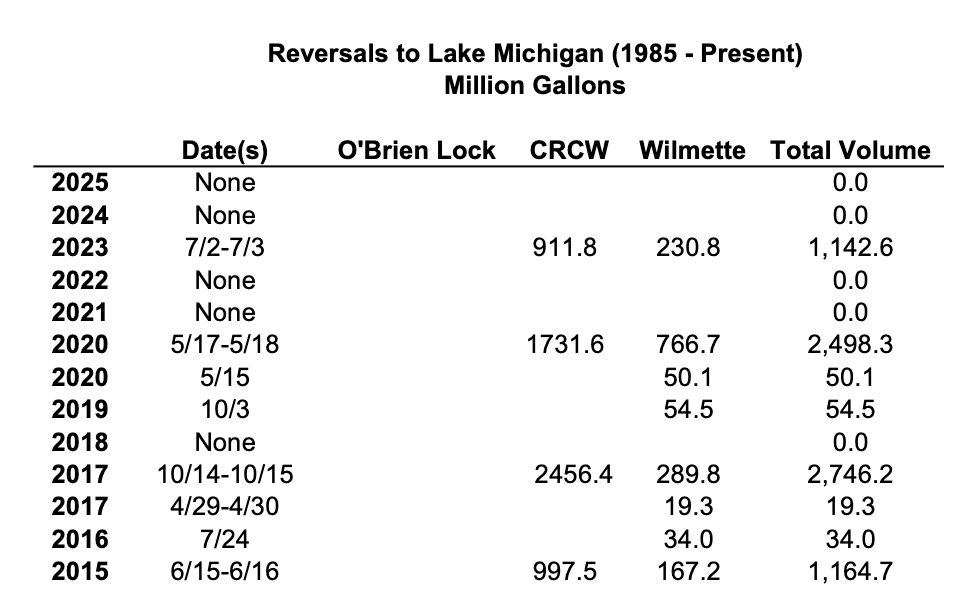

In [7]:
import pandas as pd
import numpy as np


In [3]:
datapath = "data/CSO/"
raw_cso = pd.read_csv(datapath + "CSOEventSynopsis_cleaned.csv")

In [4]:
raw_cso

,TARP_CONNECTION,location,TideGateNum,WATERWAY_REACH,Plant,open_date,Textbox10,GateOpenPeriod
0,CDS-18,Dorchester Ave ext. (S),TG01,Little Cal R (North),Calumet,3/30/2017 11:26:08 AM,3/30/2017 11:43:21 AM,0:17:13
1,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,8/20/2016 9:13:00 AM,8/20/2016 12:39:00 PM,3:26:00
2,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,2/28/2017 6:42:00 PM,2/28/2017 7:46:00 PM,1:04:00
3,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,2/28/2017 8:12:00 PM,2/28/2017 11:59:00 PM,3:47:00
4,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,3/30/2017 2:21:29 AM,3/30/2017 4:00:07 AM,1:38:38
...,...,...,...,...,...,...,...,...
5481,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,4/29/2017 11:05:00 PM,4/30/2017 4:30:00 AM,5:25:00
5482,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,10/14/2017 1:47:00 PM,10/15/2017 9:02:00 AM,19:15:00
5483,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,10/3/2019 2:08:00 AM,10/3/2019 6:00:00 AM,3:52:00
5484,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,5/15/2020 2:40:00 AM,5/15/2020 5:20:00 AM,2:40:00


In [10]:
print(raw_cso['Plant'].unique())
print(raw_cso['WATERWAY_REACH'].unique())
print(raw_cso.dtypes)


['Calumet' 'Lake Michigan' 'Stickney' 'Pumping Station Westchester'
 'OBrien' 'Pumping Station Racine Avenue' 'Pumping Station North Branch'
 'Kirie']
['Little Cal R (North)' 'Little Cal R (South)' 'Chicago R'
 'DesPlaines Upper' 'DesPlaines Middle' 'Addison Cr' 'Salt Cr'
 'DesPlaines Lower' 'CSSC Lower (SWRP)' 'NSC Lower (NSWRP)'
 'NSC Upper (NSWRP)' 'CSSC Upper (SWRP)' 'SB Chicago R' 'SF SB Chicago R'
 'NBCR Lower (NSC Confluence)' 'NBCR Upper (NSC Confluence)' 'Weller Cr'
 nan 'Collateral Channel' 'Feehanville Ditch']
TARP_CONNECTION    object
location           object
TideGateNum        object
WATERWAY_REACH     object
Plant              object
open_date          object
Textbox10          object
GateOpenPeriod     object
dtype: object


In [18]:
#rename column
raw_cso = raw_cso.rename(columns={'Textbox10':'close_date'})
#change the date time to datetime that can be used, Note from website:
# NOTE: Current CSO events are events that occur between 12:00 AM and 11:59 PM of the current day

raw_cso['open_datetime_central_time'] = pd.to_datetime(raw_cso['open_date'], errors='coerce').dt.tz_localize('America/Chicago')
raw_cso['close_datetime_central_time'] = pd.to_datetime(raw_cso['close_date'], errors='coerce').dt.tz_localize('America/Chicago')


print(raw_cso.dtypes)
raw_cso

TARP_CONNECTION                                         object
location                                                object
TideGateNum                                             object
WATERWAY_REACH                                          object
Plant                                                   object
open_date                                               object
close_date                                              object
GateOpenPeriod                                          object
open_datetime_central_time     datetime64[ns, America/Chicago]
close_datetime_central_time    datetime64[ns, America/Chicago]
dtype: object


,TARP_CONNECTION,location,TideGateNum,WATERWAY_REACH,Plant,open_date,close_date,GateOpenPeriod,open_datetime_central_time,close_datetime_central_time
0,CDS-18,Dorchester Ave ext. (S),TG01,Little Cal R (North),Calumet,3/30/2017 11:26:08 AM,3/30/2017 11:43:21 AM,0:17:13,2017-03-30 11:26:08-05:00,2017-03-30 11:43:21-05:00
1,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,8/20/2016 9:13:00 AM,8/20/2016 12:39:00 PM,3:26:00,2016-08-20 09:13:00-05:00,2016-08-20 12:39:00-05:00
2,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,2/28/2017 6:42:00 PM,2/28/2017 7:46:00 PM,1:04:00,2017-02-28 18:42:00-06:00,2017-02-28 19:46:00-06:00
3,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,2/28/2017 8:12:00 PM,2/28/2017 11:59:00 PM,3:47:00,2017-02-28 20:12:00-06:00,2017-02-28 23:59:00-06:00
4,CDS-45,9th Ave ext. & 151st St (S),TG05,Little Cal R (South),Calumet,3/30/2017 2:21:29 AM,3/30/2017 4:00:07 AM,1:38:38,2017-03-30 02:21:29-05:00,2017-03-30 04:00:07-05:00
...,...,...,...,...,...,...,...,...,...,...
5481,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,4/29/2017 11:05:00 PM,4/30/2017 4:30:00 AM,5:25:00,2017-04-29 23:05:00-05:00,2017-04-30 04:30:00-05:00
5482,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,10/14/2017 1:47:00 PM,10/15/2017 9:02:00 AM,19:15:00,2017-10-14 13:47:00-05:00,2017-10-15 09:02:00-05:00
5483,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,10/3/2019 2:08:00 AM,10/3/2019 6:00:00 AM,3:52:00,2019-10-03 02:08:00-05:00,2019-10-03 06:00:00-05:00
5484,Wilmette Gate,Wilmette Gate,ALL,NSC Upper (NSWRP),Lake Michigan,5/15/2020 2:40:00 AM,5/15/2020 5:20:00 AM,2:40:00,2020-05-15 02:40:00-05:00,2020-05-15 05:20:00-05:00


These should be tested in the model for which lock openings are relevant

I'm going to implement a feature naming convention now: 
 Feature naming convention for this project:

     {source}_{variable}_{operation}_{window}

 - source:    where the data came from (coc, usgs, beach, season, etc.)

 - variable:  what's being measured (precip, temp, wind, etc.)

 - operation: how it was aggregated (sum, max, mean, count, lag)
 
 - window:    over what time period (24h, 7d, 6h)

 Examples:

   coc_precip_sum_24h     -> sum of COC precip over 24h before sample

   coc_precip_max_6h      -> max single-bucket COC precip in last 6h

   usgs_precip_sum_7d     -> sum of USGS precip over 7 days

   season_sin_doy         -> sin of day-of-year (no source/window needed)

 Rule: if you change ONE thing about a feature, only ONE slot in the
 name should change. This makes filtering by prefix easy.

time to make lock opening info:
Also to incorporate are the lock openings, which happen so rarely they're here
https://mwrd.org/sites/default/files/2026-02/Reversals_2026_02_03.pdf
: ![image.png](attachment:image.png)